# Regularize attention maps for medical imaging

In this notebook we outline the basics of Attention Regularization project and consider a few examples of regularizing medical images

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Model

We start with adopting a model that produces attention (saliency) maps. 

In this example we use a DINO-ViT patch-8 model from facebookresearch with custom implementation via LightningModule (LitModel), fine-tuned on the ImageNet data.

In [2]:
import torch
from torchvision import transforms
from attnreg.LitModel import LitModel


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

lit_model = (
    LitModel.load_from_checkpoint(
        "../attnreg/best-checkpoint-full-imgnet-augment.ckpt"
    )
    .to(DEVICE)
    .eval()
)

# This is ViT backbone with head=nn.Identity()
model = lit_model.model
# Set the head to be the linear classifier 
model.head = lit_model.linear

Using cache found in /home/maxim/.cache/torch/hub/facebookresearch_dino_main


We put it in a high-level wrapper to unify image processing routines.

All images processed by the model will be rescaled and normalized equally.

In [3]:
from attnreg.attention import ViTWrapper

patch_size = 8
img_size = (488, 488) # size to rescale the images
normalization = ((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)) # normalize the image tensors accordingly to ImageNet processing routines

vit_wrapper = ViTWrapper(
    model=model,
    img_size=img_size,
    patch_size=patch_size,
    device=DEVICE,
    preprocess=None,
    normalization=normalization,
)

In fact we can just create a wrapper with a default model (see below), but with this example we wanted to illustrate a general model implementation procedure.

## Regularization

Here we create a custom regularization procedure to go through all the essential steps of regularization. We should specify the following attributes of the regularization procedure:

1) Bootstrap method: provided as a 'BootstrapFunc' function from 'attnreg.bootstrap' module. The bootstrap method is provided alongside a number of arguments ('bootstrap_kwargs') specified for each method. 
2) Number of bootstrap samples 'bootstrap_N'
3) Regularization threshold values: p-threshold, LFDR-threshold and z-threshold

In our example p- and l-thresholds can be computed from the p- and l-values accordingly and set as their median value. 

In [4]:
from attnreg.bootstrap import BootstrapFunc
from attnreg.regularization import attention_uncertainty, regularize_attention_all
from attnreg.plotting import plot_statistics, plot_attention
from PIL import Image

def regularize_custom(
    model_wrapper: ViTWrapper, 
    img_path: str, 
    bootstrap_function: BootstrapFunc, 
    bootstrap_kwargs: dict,
    bootstrap_N: int = 1,
    p_th: str | float = "median", 
    l_th: str | float = "median", 
    z_th: float = 0.0
) -> tuple[np.ndarray, np.ndarray, np.ndarray, float, np.ndarray, Image.Image]:

    # Load image 
    sample_img, original_img = model_wrapper.load_img(img_path,show=True)

    # Create a bootstrap sample and compute all the statistics for the image
    l, z, null_am_zz, p, pi0, obs_am, null_am, perturbed_images, _, _ = (
        attention_uncertainty(
            model_wrapper, 
            sample_img, 
            bootstrap_method=bootstrap_function, 
            bootstrap_kwargs=bootstrap_kwargs, 
            bootstrap_N=bootstrap_N, 
            pi0_prior="estimate", 
            draw=False,
        )
    )

    # Plot LFDR, p-value and z-scores distribution - the latter for the null attention scores and the original attention scores
    plot_statistics(z,p,l,null_am_zz)

    # Set p- and l-threshdolds to the median values of p- and l-values
    if p_th == "median":
        p_th = round(np.percentile(p, 50),2)
    if l_th == "median":
        l_th = round(np.percentile(l, 50),2)

    # Get regularized attention maps using the statistics
    obs_p, obs_ppw, obs_lfdr, obs_pi0, obs_am, l, z, p, pi0 = regularize_attention_all(l,z,p,pi0,obs_am,p_th=p_th,lfdr_th=l_th,z_th=z_th)

    
    # Plot the original attention map alongside regularized attention maps
    plot_attention(
        original=original_img, 
        maps= [obs_am, obs_p, obs_lfdr, obs_pi0], # we show the results of different regularization methods
        stats = [],
        titles=["Attention", f"p < {p_th}", f"l < {l_th}", r"$\pi_0$ reg"], # we specify the corresponding thresholds 
        figsize=(18, 7)
    )
    
    return l, z, p, pi0, obs_am, original_img
    

We take the Malignant case 21 from the IQ-OTHNCCD lung cancer dataset and reproducing the histograms from Fig. S13 in the paper. For that we use the parametric bootstrap from normal distribution and set the p- and l-thresholds to the median values.

(The attention map structure is not the same as in Fig. S13 and corresponds rather to the structure of Fig. S12, however we do not consider Malignant case 21 there)

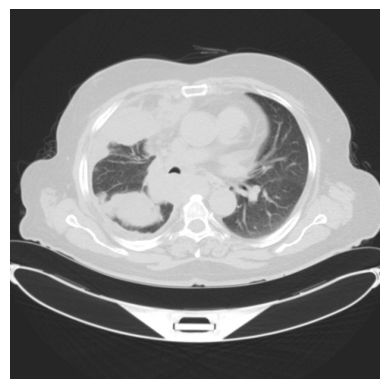

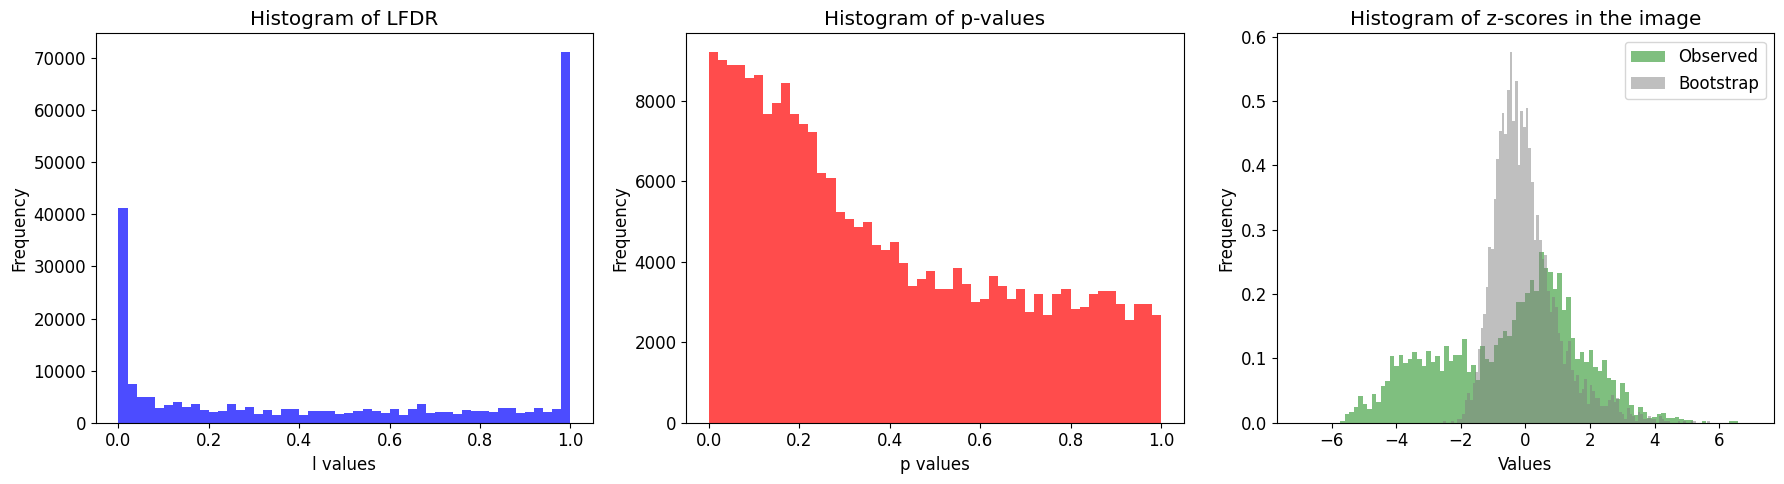

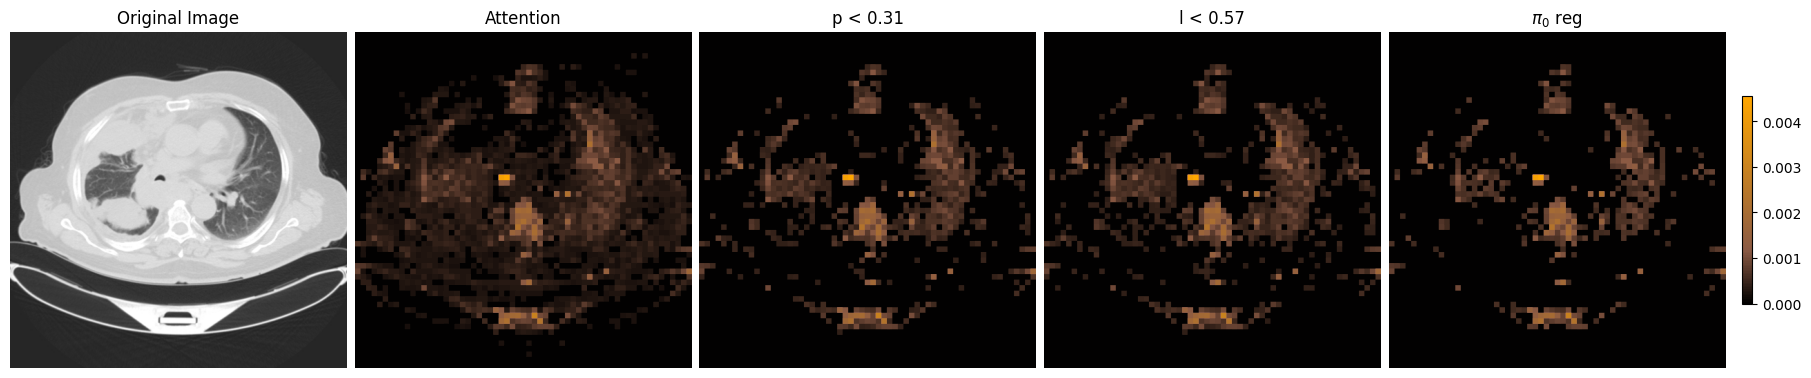

In [5]:
from attnreg.bootstrap import bootstrap_normal

result = regularize_custom(
    vit_wrapper,
    "../images/IQ-OTHNCCD_dataset/Malignant cases/Malignant case (21).jpg",
    bootstrap_function=bootstrap_normal,
    bootstrap_kwargs= {"all_channels": False,"draw": False,"seed": 0},
    bootstrap_N=1, 
    p_th="median",
    l_th="median"
) 


In fact we can achieve the same result with a built-in regularization function and a default ViT with default wrapper settings.

Let's use it for Normal case 18 - reproducing the bottom line of Fig. S12

Using cache found in /home/maxim/.cache/torch/hub/facebookresearch_dino_main


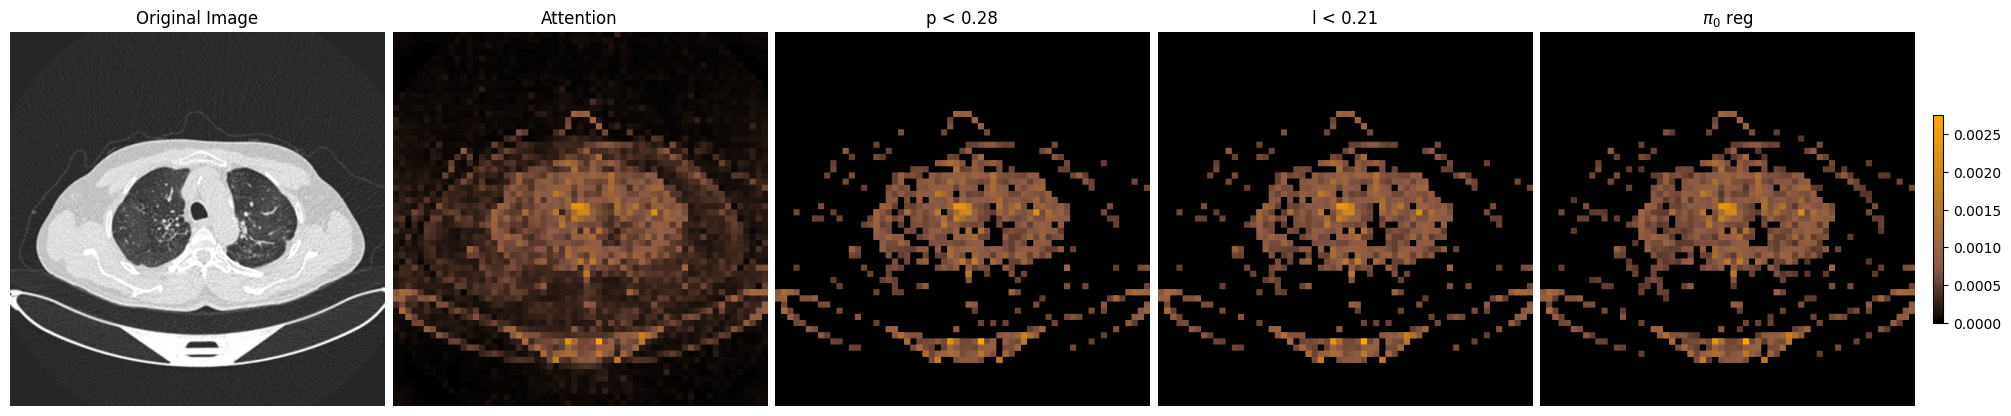

In [8]:
from attnreg.regularization import regularize

default_wrapper = ViTWrapper.default()

result2 = regularize(
    default_wrapper,
    "../images/IQ-OTHNCCD_dataset/Normal cases/Normal case (18).jpg",
    bootstrap_function=bootstrap_normal,
    bootstrap_kwargs= {"all_channels": True,"draw": False,"seed": 0},
    bootstrap_N=1, 
    p_percentile=50,
    l_percentile=50,
    draw_original=False,
    draw_attention=True, 
)

## Studying various thresholds and its impact on regularization efficiency

We can now try different thershold values for p-regularization and l-regularization independently and reproducing Fig. S13 (Malignant case 21). For that we recycle the results of our custom regularization function ('result'), as it operated on the same image.

We also plot the regularization efficiency for these cases: attention scores after regularization vs. attentions scores before regularization

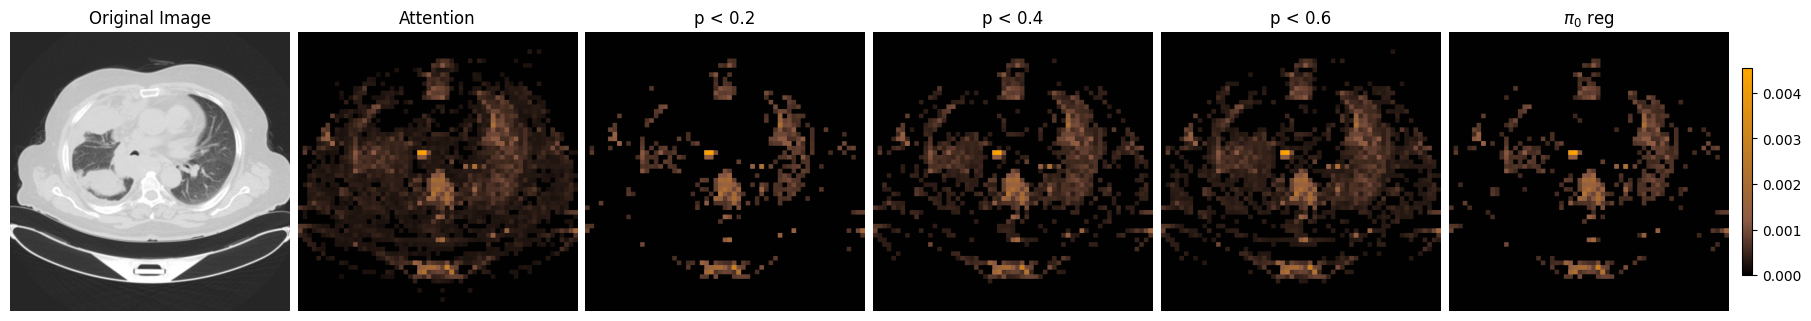

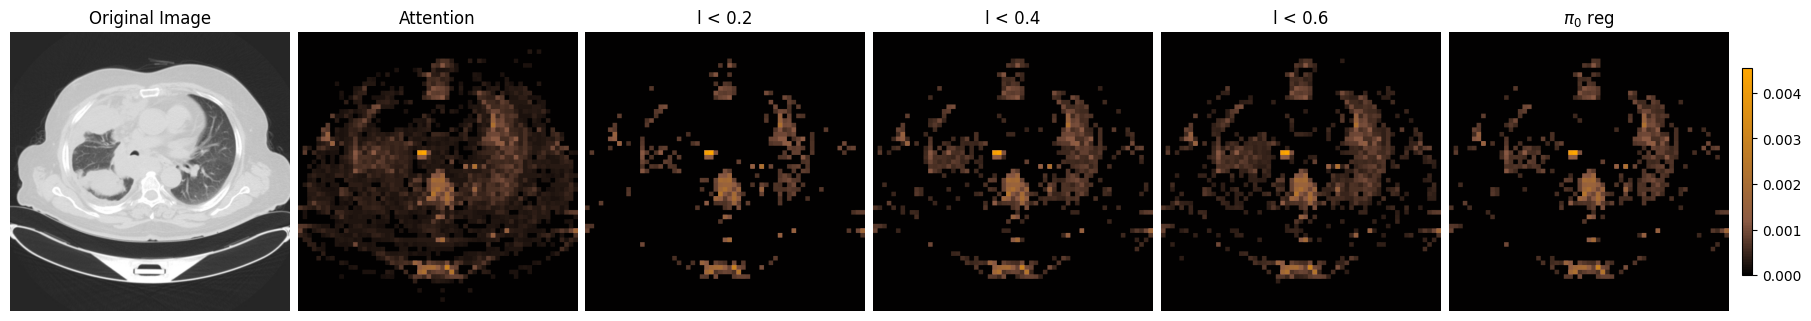

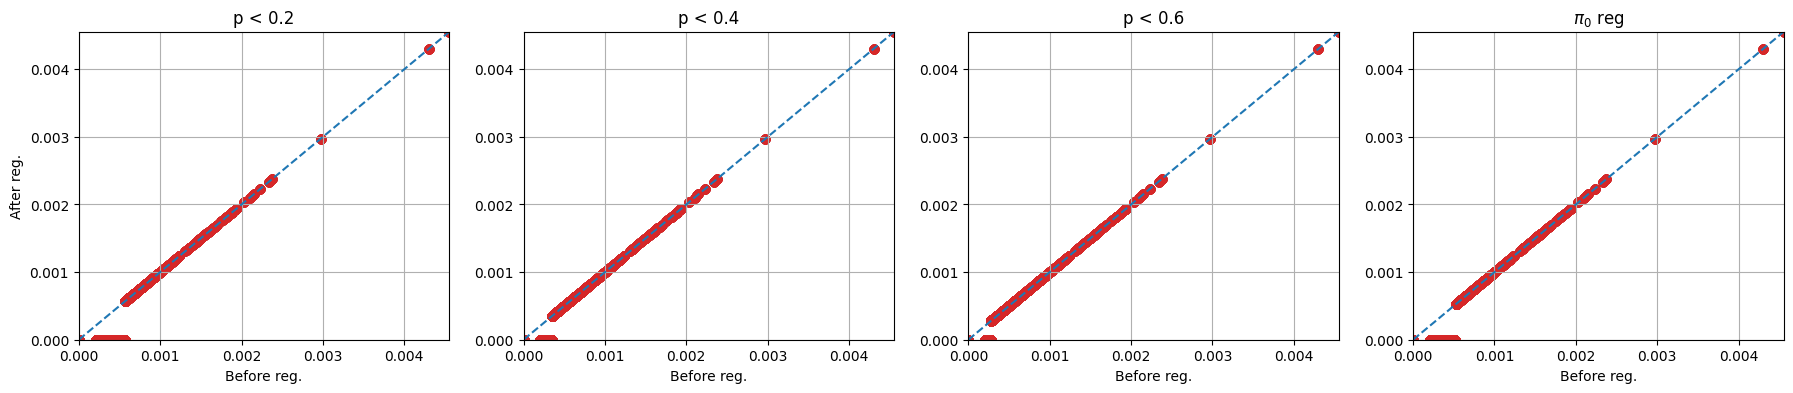

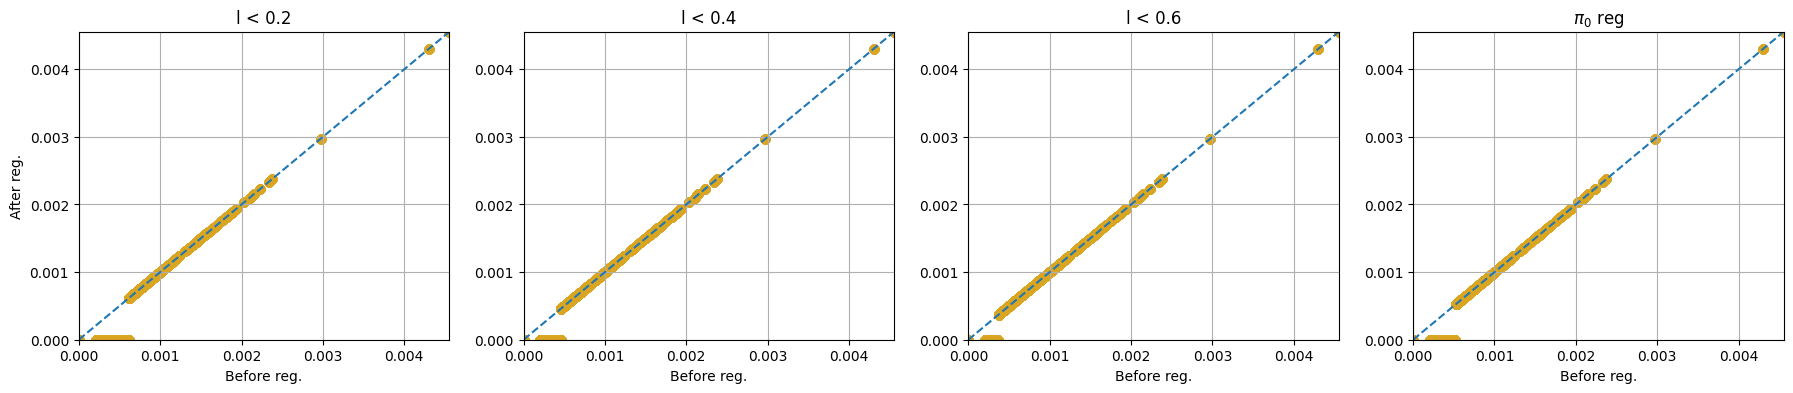

In [9]:
from attnreg.regularization import regularize_attention_all
from attnreg.plotting import plot_attention_scores_before_and_after

l, z, p, pi0, obs_am, original_img = result

# Regularize with different threshold levels
obs_p, obs_ppw, obs_lfdr, obs_pi0, _, _, _, _, _ = regularize_attention_all(l,z,p,pi0,obs_am,p_th=0.2,lfdr_th=0.2)
obs_p2, _, obs_l2, _, _, _, _, _, _ = regularize_attention_all(l,z,p,pi0,obs_am,p_th=0.4,lfdr_th=0.4)
obs_p3, _, obs_l3, _, _, _, _, _, _ = regularize_attention_all(l,z,p,pi0,obs_am,p_th=0.6,lfdr_th=0.6)

plot_attention(
    original=original_img, 
    maps=[obs_am, obs_p, obs_p2, obs_p3, obs_pi0], 
    stats=[],
    titles=["Attention", "p < 0.2", "p < 0.4","p < 0.6", r"$\pi_0$ reg"], 
    figsize=(18, 7)
)
plot_attention(
    original=original_img, 
    maps=[obs_am, obs_lfdr, obs_l2, obs_l3, obs_pi0], 
    stats=[],
    titles=["Attention", "l < 0.2", "l < 0.4","l < 0.6", r"$\pi_0$ reg"], 
    figsize=(18, 7)
)


plot_attention_scores_before_and_after(
    am_before=obs_am, 
    ams_reg=[obs_p, obs_p2, obs_p3, obs_pi0],
    titles=["p < 0.2", "p < 0.4","p < 0.6", r"$\pi_0$ reg"],
    color="tab:red",
    figsize=(22, 4)
)
plot_attention_scores_before_and_after(
    am_before=obs_am, 
    ams_reg=[obs_lfdr, obs_l2, obs_l3, obs_pi0],
    titles=["l < 0.2", "l < 0.4","l < 0.6", r"$\pi_0$ reg"],
    color="goldenrod",
    figsize=(22, 4)
)

